In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("processed_music_dataset.csv")

print(df.head())

                  artists                  track_name  popularity  \
0             Gen Hoshino                      Comedy          73   
1            Ben Woodward            Ghost - Acoustic          55   
2  Ingrid Michaelson;ZAYN              To Begin Again          57   
3            Kina Grannis  Can't Help Falling In Love          71   
4        Chord Overstreet                     Hold On          82   

   duration_ms  explicit  danceability  energy  key  loudness  mode  \
0       230666         0         0.676  0.4610    1    -6.746     0   
1       149610         0         0.420  0.1660    1   -17.235     1   
2       210826         0         0.438  0.3590    0    -9.734     1   
3       201933         0         0.266  0.0596    0   -18.515     1   
4       198853         0         0.618  0.4430    2    -9.681     1   

   speechiness  acousticness  instrumentalness  liveness  valence    tempo  \
0       0.1430        0.0322          0.000001    0.3580    0.715   87.917   
1 

In [3]:
feature_columns = [
'danceability',
'energy',
'loudness',
'speechiness',
'acousticness',
'instrumentalness',
'liveness',
'valence',
'tempo'
]

features = df[feature_columns]

In [4]:
# Select Feature Columns for Clustering

X = df[feature_columns]

In [5]:
X.shape

(81344, 9)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


C:\Users\santo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\santo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\santo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\santo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

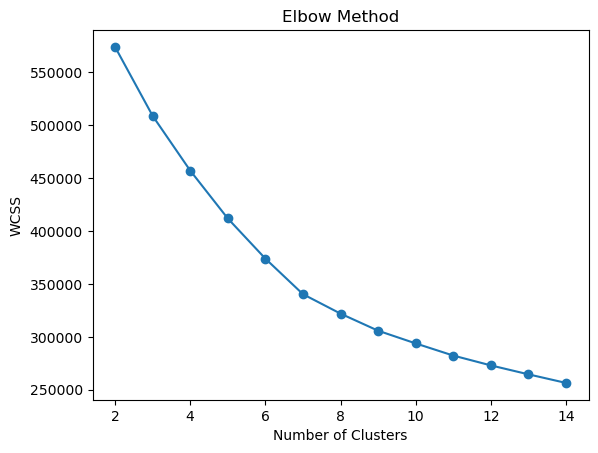

In [7]:
# Determine Best Number of Clusters (Elbow Method)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 15):

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,15), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()


In [8]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters


In [9]:
print(df['cluster'].value_counts())


cluster
6    17034
1    13654
7    12700
9    10500
4     6405
2     5898
3     5293
0     4568
8     4383
5      909
Name: count, dtype: int64


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


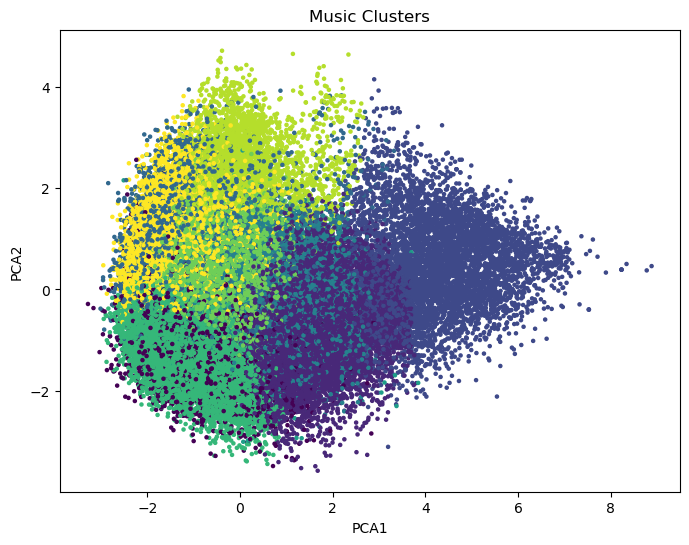

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['cluster'],
    cmap='viridis',
    s=5
)

plt.title("Music Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()


In [12]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")


['kmeans_model.pkl']

In [13]:
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [20]:
# Function to Get Songs From Same Cluster
def get_cluster_songs(song_index):

    cluster_id = df.iloc[song_index]['cluster']

    cluster_songs = df[df['cluster'] == cluster_id]

    return cluster_songs


In [21]:
songs = get_cluster_songs(100)

print(songs[['track_name','artists']].head())


                    track_name                               artists
1             Ghost - Acoustic                          Ben Woodward
3   Can't Help Falling In Love                          Kina Grannis
4                      Hold On                      Chord Overstreet
6                Say Something  A Great Big World;Christina Aguilera
10        Give Me Your Forever                          Zack Tabudlo


In [22]:
# Connect Clustering With Cosine Similarity

from sklearn.metrics.pairwise import cosine_similarity

cluster_data = X_scaled[df['cluster'] == 3]

similarity_matrix = cosine_similarity(cluster_data)


In [23]:
def recommend(song_index):

    cluster_id = df.iloc[song_index]['cluster']

    cluster_df = df[df['cluster'] == cluster_id]

    cluster_features = X_scaled[df['cluster'] == cluster_id]

    similarity = cosine_similarity(cluster_features)

    idx = cluster_df.index.get_loc(song_index)

    scores = list(enumerate(similarity[idx]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top = scores[1:6]

    return cluster_df.iloc[[i[0] for i in top]][['track_name','artists']]


In [24]:
recommend(100)


,track_name,artists
32634,Oh Quão Cego Andei,Pr. Júlio Ribeiro
518,Scared to Be Lonely,Boyce Avenue
233,Back For Good,The Mayries
13172,Inside Out,Mokita
16670,Better Boat,Kenny Chesney;Mindy Smith


In [14]:
df.to_csv("processed_music_dataset2.csv", index=False)